# BENCHMARK: Fine-tuned Models vs Original Models

Notebook này sẽ đánh giá và so sánh 3 model embedding đã fine-tune với các model gốc:

## Models được đánh giá:

### Fine-tuned Models:
- **Google Gemma Embeddings** (300M) - Fine-tuned
- **BAAI BGE-M3** - Fine-tuned
- **all-MiniLM-L6-v2** (22M) - Fine-tuned

### Original Models:
- **Google Gemma Embeddings** (300M) - Original
- **BAAI BGE-M3** - Original
- **all-MiniLM-L6-v2** (22M) - Original

## Metrics được đánh giá:
- Recall@k (k=1,3,5,10)
- MRR@k (Mean Reciprocal Rank)
- nDCG@k (Normalized Discounted Cumulative Gain)
- Context Precision@k
- Similarity Distribution
- Accuracy at different thresholds

In [22]:
# Install required packages if needed
# !pip install sentence-transformers torch transformers numpy scikit-learn matplotlib seaborn pandas tqdm

In [23]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple
from tqdm import tqdm
import torch
from sklearn.metrics.pairwise import cosine_similarity

# Add parent directory to path
sys.path.append(str(Path.cwd()))

# Import evaluation utilities
from evaluation_utils import EmbeddingEvaluator
from data_loader import EmbeddingDataLoader

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("Imports successful!")

Imports successful!


In [24]:
# Configuration
BASE_DIR = Path("/home/nhotin/work/LegalBizAI_project/finetune/embedding_models")
DATA_PATH = "/home/nhotin/work/LegalBizAI_project/finetune/data_finetunning/qaset_article.json"
K_VALUES = [1, 3, 5, 10]
# Use GPU for faster processing - models will be loaded one at a time
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

print(f"Base directory: {BASE_DIR}")
print(f"Data path: {DATA_PATH}")
print(f"Device: {DEVICE} ({'GPU' if DEVICE == 'cuda' else 'CPU'})")
print(f"K values: {K_VALUES}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

Base directory: /home/nhotin/work/LegalBizAI_project/finetune/embedding_models
Data path: /home/nhotin/work/LegalBizAI_project/finetune/data_finetunning/qaset_article.json
Device: cuda (GPU)
K values: [1, 3, 5, 10]
GPU: NVIDIA GeForce RTX 5060 Ti
GPU Memory: 15.44 GB


In [ ]:
# Model paths - Fine-tuned models
# ✅ Sửa BGE-M3: dùng best_model thay vì final_model
FINETUNED_MODEL_PATHS = {
    "gemma": BASE_DIR / "google_gemma_embeddings" / "output" / "gemma" / "final_model",
    "bge_m3": BASE_DIR / "baai_bge_m3" / "output" / "bge_m3" / "best_model",  
    "minilm": BASE_DIR / "all_minilm_l6_v2" / "output" / "minilm"
}

# Original model names (from HuggingFace)
ORIGINAL_MODEL_NAMES = {
    "gemma": "google/embeddinggemma-300m",
    "bge_m3": "BAAI/bge-m3",
    "minilm": "sentence-transformers/all-MiniLM-L6-v2"
}

# Model display names
MODEL_DISPLAY_NAMES = {
    "gemma": "Google Gemma (300M)",
    "bge_m3": "BAAI BGE-M3",
    "minilm": "all-MiniLM-L6-v2 (22M)"
}

# Check if fine-tuned models exist
print("Checking fine-tuned model paths...")
for model_key, model_path in FINETUNED_MODEL_PATHS.items():
    exists = model_path.exists()
    status = "ok" if exists else "0ko"
    print(f"{status} {MODEL_DISPLAY_NAMES[model_key]} (Fine-tuned): {model_path}")

print("\nOriginal models will be loaded from HuggingFace:")
for model_key, model_name in ORIGINAL_MODEL_NAMES.items():
    print(f"   {MODEL_DISPLAY_NAMES[model_key]} (Original): {model_name}")

Checking fine-tuned model paths...
ok Google Gemma (300M) (Fine-tuned): /home/nhotin/work/LegalBizAI_project/finetune/embedding_models/google_gemma_embeddings/output/gemma/final_model
ok BAAI BGE-M3 (Fine-tuned): /home/nhotin/work/LegalBizAI_project/finetune/embedding_models/baai_bge_m3/output/bge_m3/best_model
ok all-MiniLM-L6-v2 (22M) (Fine-tuned): /home/nhotin/work/LegalBizAI_project/finetune/embedding_models/all_minilm_l6_v2/output/minilm

Original models will be loaded from HuggingFace:
   Google Gemma (300M) (Original): google/embeddinggemma-300m
   BAAI BGE-M3 (Original): BAAI/bge-m3
   all-MiniLM-L6-v2 (22M) (Original): sentence-transformers/all-MiniLM-L6-v2


In [26]:
# Load test data
data_loader = EmbeddingDataLoader(
    data_path=DATA_PATH,
    test_split=0.2,
    seed=42
)

test_data = data_loader.get_test_data()
print(f"Loaded {len(test_data)} test samples")

# Get queries and answers
queries = [item['question'] for item in test_data]
answers = [item['answer'] for item in test_data]

print(f"Queries: {len(queries)}")
print(f"Answers: {len(answers)}")
print(f"\nSample query:\n{queries[0][:200]}...")
print(f"\nSample answer:\n{answers[0][:200]}...")

Loaded 508 test samples
Queries: 508
Answers: 508

Sample query:
Giám đốc Công ty TNHH một thành viên do Nhà nước nắm giữ 100% vốn điều lệ là người có quan hệ gia đình với Phó chủ tịch công ty được không?...

Sample answer:
Theo quy định tại khoản 2 Điều 88 Luật Doanh nghiệp 2020 thì Doanh nghiệp do Nhà nước nắm giữ 100% vốn điều lệ bao gồm:
- Công ty trách nhiệm hữu hạn một thành viên do Nhà nước nắm giữ 100% vốn điều l...


In [27]:
def load_model(model_path_or_name: str, is_finetuned: bool = True, device: str = "cuda"):
    """Load embedding model from path (fine-tuned) or HuggingFace name (original)"""
    from sentence_transformers import SentenceTransformer
    
    try:
        if is_finetuned:
            # Load fine-tuned model from local path
            model = SentenceTransformer(str(model_path_or_name), device=device)
        else:
            # Load original model from HuggingFace
            model = SentenceTransformer(model_path_or_name, device=device)
        return model
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

def clear_gpu_memory():
    """Clear GPU memory cache"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        import gc
        gc.collect()

def get_gpu_memory_info():
    """Get current GPU memory usage"""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated(0) / 1024**3
        reserved = torch.cuda.memory_reserved(0) / 1024**3
        return f"GPU Memory: {allocated:.2f}GB allocated, {reserved:.2f}GB reserved"
    return "CPU mode"

# ✅ Tối ưu: Load và benchmark từng model một, sau đó xóa để tiết kiệm VRAM
# Không load tất cả models cùng lúc nữa - sẽ load từng cái một trong Cell 7
print("✅ Đã chuẩn bị functions để load model và clear GPU memory")
print(f"   Device: {DEVICE}")
print(f"   {get_gpu_memory_info()}")

✅ Đã chuẩn bị functions để load model và clear GPU memory
   Device: cuda
   GPU Memory: 0.00GB allocated, 3.41GB reserved


In [28]:
def generate_embeddings(model, texts: List[str], batch_size: int = 32, desc: str = "Generating embeddings"):
    """Generate embeddings for a list of texts"""
    embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch = texts[i:i + batch_size]
        batch_embeddings = model.encode(batch, convert_to_numpy=True, show_progress_bar=False)
        embeddings.append(batch_embeddings)
    
    return np.vstack(embeddings)

# ✅ Tối ưu: Load từng model một, generate embeddings, benchmark, rồi xóa để tiết kiệm VRAM
print("=" * 100)
print("GENERATING EMBEDDINGS - Loading models one at a time to save VRAM")
print("=" * 100)

all_embeddings = {}
all_results = {}  # Store results here too

# Process each model pair (fine-tuned + original) one at a time
for base_model_key in ['gemma', 'bge_m3', 'minilm']:
    print(f"\n{'='*100}")
    print(f"Processing {MODEL_DISPLAY_NAMES[base_model_key]}...")
    print(f"{'='*100}")
    
    # 1. Load and process FINE-TUNED model
    finetuned_path = FINETUNED_MODEL_PATHS[base_model_key]
    if finetuned_path.exists():
        print(f"\n[1/2] Loading Fine-tuned model: {MODEL_DISPLAY_NAMES[base_model_key]}")
        print(f"   Path: {finetuned_path}")
        print(f"   {get_gpu_memory_info()}")
        
        model_finetuned = load_model(str(finetuned_path), is_finetuned=True, device=DEVICE)
        if model_finetuned is not None:
            print(f"   ✓ Loaded - Dimension: {model_finetuned.get_sentence_embedding_dimension()}")
            print(f"   {get_gpu_memory_info()}")
            
            # Generate embeddings
            print(f"\n   Generating embeddings...")
            query_embeddings_ft = generate_embeddings(
                model_finetuned, queries, 
                batch_size=BATCH_SIZE, 
                desc=f"   Query embeddings (Fine-tuned)"
            )
            answer_embeddings_ft = generate_embeddings(
                model_finetuned, answers, 
                batch_size=BATCH_SIZE, 
                desc=f"   Answer embeddings (Fine-tuned)"
            )
            
            all_embeddings[f"{base_model_key}_finetuned"] = {
                'query': query_embeddings_ft,
                'answer': answer_embeddings_ft
            }
            
            print(f"   ✓ Query embeddings shape: {query_embeddings_ft.shape}")
            print(f"   ✓ Answer embeddings shape: {answer_embeddings_ft.shape}")
            
            # Clear model from GPU
            del model_finetuned
            clear_gpu_memory()
            print(f"   ✓ Cleared GPU memory")
            print(f"   {get_gpu_memory_info()}")
        else:
            print(f"   ✗ Failed to load fine-tuned model")
    else:
        print(f"\n[1/2] Fine-tuned model not found: {finetuned_path}")
    
    # 2. Load and process ORIGINAL model
    original_name = ORIGINAL_MODEL_NAMES[base_model_key]
    print(f"\n[2/2] Loading Original model: {MODEL_DISPLAY_NAMES[base_model_key]}")
    print(f"   HuggingFace: {original_name}")
    print(f"   {get_gpu_memory_info()}")
    
    model_original = load_model(original_name, is_finetuned=False, device=DEVICE)
    if model_original is not None:
        print(f"   ✓ Loaded - Dimension: {model_original.get_sentence_embedding_dimension()}")
        print(f"   {get_gpu_memory_info()}")
        
        # Generate embeddings
        print(f"\n   Generating embeddings...")
        query_embeddings_orig = generate_embeddings(
            model_original, queries, 
            batch_size=BATCH_SIZE, 
            desc=f"   Query embeddings (Original)"
        )
        answer_embeddings_orig = generate_embeddings(
            model_original, answers, 
            batch_size=BATCH_SIZE, 
            desc=f"   Answer embeddings (Original)"
        )
        
        all_embeddings[f"{base_model_key}_original"] = {
            'query': query_embeddings_orig,
            'answer': answer_embeddings_orig
        }
        
        print(f"   ✓ Query embeddings shape: {query_embeddings_orig.shape}")
        print(f"   ✓ Answer embeddings shape: {answer_embeddings_orig.shape}")
        
        # Clear model from GPU
        del model_original
        clear_gpu_memory()
        print(f"   ✓ Cleared GPU memory")
        print(f"   {get_gpu_memory_info()}")
    else:
        print(f"   ✗ Failed to load original model")
    
    print(f"\n✓ Completed {MODEL_DISPLAY_NAMES[base_model_key]}")

print(f"\n{'='*100}")
print(f"✓ Generated embeddings for {len(all_embeddings)} models")
print(f"{'='*100}")

GENERATING EMBEDDINGS - Loading models one at a time to save VRAM

Processing Google Gemma (300M)...

[1/2] Loading Fine-tuned model: Google Gemma (300M)
   Path: /home/nhotin/work/LegalBizAI_project/finetune/embedding_models/google_gemma_embeddings/output/gemma/final_model
   GPU Memory: 0.00GB allocated, 3.41GB reserved
   ✓ Loaded - Dimension: 768
   GPU Memory: 1.15GB allocated, 3.41GB reserved

   Generating embeddings...


   Answer embeddings (Fine-tuned): 100%|██████████| 16/16 [00:09<00:00,  1.71it/s]


   ✓ Query embeddings shape: (508, 768)
   ✓ Answer embeddings shape: (508, 768)
   ✓ Cleared GPU memory
   GPU Memory: 0.01GB allocated, 1.22GB reserved

[2/2] Loading Original model: Google Gemma (300M)
   HuggingFace: google/embeddinggemma-300m
   GPU Memory: 0.01GB allocated, 1.22GB reserved
   ✓ Loaded - Dimension: 768
   GPU Memory: 1.15GB allocated, 1.22GB reserved

   Generating embeddings...


   Answer embeddings (Original): 100%|██████████| 16/16 [00:18<00:00,  1.14s/it]


   ✓ Query embeddings shape: (508, 768)
   ✓ Answer embeddings shape: (508, 768)
   ✓ Cleared GPU memory
   GPU Memory: 0.01GB allocated, 1.20GB reserved

✓ Completed Google Gemma (300M)

Processing BAAI BGE-M3...

[1/2] Loading Fine-tuned model: BAAI BGE-M3
   Path: /home/nhotin/work/LegalBizAI_project/finetune/embedding_models/baai_bge_m3/output/bge_m3/best_model
   GPU Memory: 0.01GB allocated, 1.20GB reserved


...

   ✓ Query embeddings shape: (508, 1024)
   ✓ Answer embeddings shape: (508, 1024)
   ✓ Cleared GPU memory
   GPU Memory: 0.01GB allocated, 2.15GB reserved

✓ Completed BAAI BGE-M3

Processing all-MiniLM-L6-v2 (22M)...

[1/2] Loading Fine-tuned model: all-MiniLM-L6-v2 (22M)
   Path: /home/nhotin/work/LegalBizAI_project/finetune/embedding_models/all_minilm_l6_v2/output/minilm
   GPU Memory: 0.01GB allocated, 2.15GB reserved
   ✓ Loaded - Dimension: 384
   GPU Memory: 0.09GB allocated, 2.16GB reserved

   Generating embeddings...


   Answer embeddings (Fine-tuned): 100%|██████████| 16/16 [00:00<00:00, 18.06it/s]


   ✓ Query embeddings shape: (508, 384)
   ✓ Answer embeddings shape: (508, 384)
   ✓ Cleared GPU memory
   GPU Memory: 0.01GB allocated, 0.81GB reserved

[2/2] Loading Original model: all-MiniLM-L6-v2 (22M)
   HuggingFace: sentence-transformers/all-MiniLM-L6-v2
   GPU Memory: 0.01GB allocated, 0.81GB reserved
   ✓ Loaded - Dimension: 384
   GPU Memory: 0.09GB allocated, 0.81GB reserved

   Generating embeddings...


   Answer embeddings (Original): 100%|██████████| 16/16 [00:00<00:00, 18.03it/s]


   ✓ Query embeddings shape: (508, 384)
   ✓ Answer embeddings shape: (508, 384)
   ✓ Cleared GPU memory
   GPU Memory: 0.01GB allocated, 0.81GB reserved

✓ Completed all-MiniLM-L6-v2 (22M)

✓ Generated embeddings for 6 models


In [29]:
def evaluate_model(model_key: str, query_embeddings: np.ndarray, answer_embeddings: np.ndarray, 
                   test_data: List[Dict], k_values: List[int]) -> Dict:
    """Evaluate a single model and return all metrics"""
    
    # Extract base model key by removing suffix (_finetuned or _original)
    base_key = model_key.replace('_finetuned', '').replace('_original', '')
    model_type = "Fine-tuned" if "finetuned" in model_key else "Original"
    model_display_name = MODEL_DISPLAY_NAMES[base_key]
    
    print(f"\nEvaluating {model_display_name} ({model_type})...")
    
    # Calculate similarity matrix
    similarity_matrix = cosine_similarity(query_embeddings, answer_embeddings)
    
    # Get relevant documents (for QA pairs, each query has one relevant answer - itself)
    relevant_docs = [[i] for i in range(len(test_data))]
    
    # Get retrieved documents (top-k by similarity)
    retrieved_docs = []
    for i in range(len(test_data)):
        # Get top-k indices sorted by similarity (descending)
        top_k_indices = np.argsort(similarity_matrix[i])[::-1][:max(k_values)]
        retrieved_docs.append(top_k_indices.tolist())
    
    # Calculate similarity scores for relevant documents
    diagonal_similarities = np.diag(similarity_matrix)
    
    # Initialize evaluator
    evaluator = EmbeddingEvaluator(k_values=k_values)
    
    # Calculate all metrics
    metrics_results = evaluator.evaluate_all_metrics(relevant_docs, retrieved_docs)
    
    # Calculate similarity statistics
    similarity_stats = {
        'mean': float(np.mean(diagonal_similarities)),
        'std': float(np.std(diagonal_similarities)),
        'min': float(np.min(diagonal_similarities)),
        'max': float(np.max(diagonal_similarities)),
        'median': float(np.median(diagonal_similarities)),
        'values': diagonal_similarities.tolist()
    }
    
    # Calculate accuracy at different thresholds
    accuracy_metrics = {}
    for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
        accuracy = float(np.mean(diagonal_similarities >= threshold))
        accuracy_metrics[f'accuracy_{threshold}'] = accuracy
    
    # Compile all results
    results = {
        'model': model_key,
        'base_model': base_key,
        'model_type': model_type,
        'model_name': f"{model_display_name} ({model_type})",
        'metrics': metrics_results,
        'similarity_stats': similarity_stats,
        'accuracy_metrics': accuracy_metrics,
        'similarity_matrix': similarity_matrix
    }
    
    print(f"   Evaluation complete")
    
    return results

# Evaluate all models (embeddings are already in memory, no need to reload models)
print("=" * 100)
print("EVALUATING ALL MODELS")
print("=" * 100)

for model_key, embeddings in all_embeddings.items():
    results = evaluate_model(
        model_key=model_key,
        query_embeddings=embeddings['query'],
        answer_embeddings=embeddings['answer'],
        test_data=test_data,
        k_values=K_VALUES
    )
    all_results[model_key] = results

print(f"\n{'='*100}")
print(f"✓ Evaluated {len(all_results)} models")
print(f"{'='*100}")

EVALUATING ALL MODELS

Evaluating Google Gemma (300M) (Fine-tuned)...
   Evaluation complete

Evaluating Google Gemma (300M) (Original)...
   Evaluation complete

Evaluating BAAI BGE-M3 (Fine-tuned)...
   Evaluation complete

Evaluating BAAI BGE-M3 (Original)...
   Evaluation complete

Evaluating all-MiniLM-L6-v2 (22M) (Fine-tuned)...
   Evaluation complete

Evaluating all-MiniLM-L6-v2 (22M) (Original)...
   Evaluation complete

✓ Evaluated 6 models


In [30]:
# Create comprehensive results DataFrame
def create_results_df(all_results: Dict) -> pd.DataFrame:
    """Create a comprehensive results DataFrame"""
    rows = []
    
    for model_key, results in all_results.items():
        model_name = results['model_name']
        base_model = results['base_model']
        model_type = results['model_type']
        metrics = results['metrics']
        similarity_stats = results['similarity_stats']
        accuracy_metrics = results['accuracy_metrics']
        
        for k in K_VALUES:
            row = {
                'Base_Model': base_model,
                'Model_Name': model_name,
                'Model_Type': model_type,
                'K': k,
                'Recall': metrics['recall'][k],
                'MRR': metrics['mrr'][k],
                'nDCG': metrics['ndcg'][k],
                'Context_Precision': metrics['context_precision'][k],
            }
            rows.append(row)
        
        # Add similarity stats (only for first row to avoid duplication)
        if rows:
            rows[-len(K_VALUES)]['Mean_Similarity'] = similarity_stats['mean']
            rows[-len(K_VALUES)]['Std_Similarity'] = similarity_stats['std']
            rows[-len(K_VALUES)]['Min_Similarity'] = similarity_stats['min']
            rows[-len(K_VALUES)]['Max_Similarity'] = similarity_stats['max']
            rows[-len(K_VALUES)]['Median_Similarity'] = similarity_stats['median']
            
            # Add accuracy metrics
            for threshold, accuracy in accuracy_metrics.items():
                rows[-len(K_VALUES)][f'Accuracy_{threshold}'] = accuracy
    
    df = pd.DataFrame(rows)
    
    # Fill NaN values for similarity stats across all k values
    for col in ['Mean_Similarity', 'Std_Similarity', 'Min_Similarity', 'Max_Similarity', 'Median_Similarity']:
        if col in df.columns:
            df[col] = df.groupby(['Base_Model', 'Model_Type'])[col].transform('first')
    
    for col in df.columns:
        if col.startswith('Accuracy_'):
            df[col] = df.groupby(['Base_Model', 'Model_Type'])[col].transform('first')
    
    return df

# Create results DataFrame
results_df = create_results_df(all_results)

print("Results Summary:")
print("=" * 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)
print(results_df.to_string(index=False))
print("\n" + "=" * 100)

Results Summary:
Base_Model                          Model_Name Model_Type  K   Recall      MRR     nDCG  Context_Precision  Mean_Similarity  Std_Similarity  Min_Similarity  Max_Similarity  Median_Similarity  Accuracy_accuracy_0.5  Accuracy_accuracy_0.6  Accuracy_accuracy_0.7  Accuracy_accuracy_0.8  Accuracy_accuracy_0.9
     gemma    Google Gemma (300M) (Fine-tuned) Fine-tuned  1 0.866142 0.866142 0.866142           0.866142         0.741189        0.126065        0.246707        0.942609           0.771366               0.937008               0.864173               0.720472               0.383858               0.027559
     gemma    Google Gemma (300M) (Fine-tuned) Fine-tuned  3 0.958661 0.907480 0.920649           0.319554         0.741189        0.126065        0.246707        0.942609           0.771366               0.937008               0.864173               0.720472               0.383858               0.027559
     gemma    Google Gemma (300M) (Fine-tuned) Fine-tuned  5 0.97

In [31]:
# Create comparison DataFrame (Fine-tuned vs Original)
comparison_rows = []

for base_model in ['gemma', 'bge_m3', 'minilm']:
    finetuned_key = f"{base_model}_finetuned"
    original_key = f"{base_model}_original"
    
    if finetuned_key in all_results and original_key in all_results:
        finetuned_results = all_results[finetuned_key]
        original_results = all_results[original_key]
        
        model_display_name = MODEL_DISPLAY_NAMES[base_model]
        
        for k in K_VALUES:
            for metric_name in ['recall', 'mrr', 'ndcg', 'context_precision']:
                finetuned_value = finetuned_results['metrics'][metric_name][k]
                original_value = original_results['metrics'][metric_name][k]
                improvement = finetuned_value - original_value
                improvement_pct = (improvement / original_value * 100) if original_value > 0 else 0
                
                comparison_rows.append({
                    'Model': model_display_name,
                    'Metric': metric_name.upper(),
                    'K': k,
                    'Original': original_value,
                    'Fine-tuned': finetuned_value,
                    'Improvement': improvement,
                    'Improvement_%': improvement_pct
                })

comparison_df = pd.DataFrame(comparison_rows)

print("COMPARISON: Fine-tuned vs Original Models")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 100)

COMPARISON: Fine-tuned vs Original Models
                 Model            Metric  K  Original  Fine-tuned  Improvement  Improvement_%
   Google Gemma (300M)            RECALL  1  0.070866    0.866142     0.795276    1122.222222
   Google Gemma (300M)               MRR  1  0.070866    0.866142     0.795276    1122.222222
   Google Gemma (300M)              NDCG  1  0.070866    0.866142     0.795276    1122.222222
   Google Gemma (300M) CONTEXT_PRECISION  1  0.070866    0.866142     0.795276    1122.222222
   Google Gemma (300M)            RECALL  3  0.165354    0.958661     0.793307     479.761905
   Google Gemma (300M)               MRR  3  0.113845    0.907480     0.793635     697.118156
   Google Gemma (300M)              NDCG  3  0.127131    0.920649     0.793518     624.173658
   Google Gemma (300M) CONTEXT_PRECISION  3  0.055118    0.319554     0.264436     479.761905
   Google Gemma (300M)            RECALL  5  0.253937    0.974409     0.720472     283.720930
   Google Gemma (3

In [32]:
# Summary statistics by model
print("SUMMARY STATISTICS BY MODEL")
print("=" * 100)

for base_model in ['gemma', 'bge_m3', 'minilm']:
    finetuned_key = f"{base_model}_finetuned"
    original_key = f"{base_model}_original"
    
    if finetuned_key in all_results and original_key in all_results:
        finetuned_results = all_results[finetuned_key]
        original_results = all_results[original_key]
        
        model_display_name = MODEL_DISPLAY_NAMES[base_model]
        
        print(f"\n{model_display_name}")
        print("-" * 100)
        
        # Similarity statistics
        print(f"\nSimilarity Statistics:")
        print(f"   {'Metric':<20} {'Original':<15} {'Fine-tuned':<15} {'Improvement':<15}")
        print(f"   {'-'*20} {'-'*15} {'-'*15} {'-'*15}")
        
        for stat_name in ['mean', 'std', 'min', 'max', 'median']:
            orig_val = original_results['similarity_stats'][stat_name]
            ft_val = finetuned_results['similarity_stats'][stat_name]
            improvement = ft_val - orig_val
            print(f"   {stat_name.capitalize():<20} {orig_val:<15.4f} {ft_val:<15.4f} {improvement:+.4f}")
        
        # Retrieval metrics
        print(f"\nRetrieval Metrics (Recall@10):")
        print(f"   {'Metric':<20} {'Original':<15} {'Fine-tuned':<15} {'Improvement':<15} {'Improvement %':<15}")
        print(f"   {'-'*20} {'-'*15} {'-'*15} {'-'*15} {'-'*15}")
        
        for metric_name in ['recall', 'mrr', 'ndcg', 'context_precision']:
            orig_val = original_results['metrics'][metric_name][10]
            ft_val = finetuned_results['metrics'][metric_name][10]
            improvement = ft_val - orig_val
            improvement_pct = (improvement / orig_val * 100) if orig_val > 0 else 0
            print(f"   {metric_name.upper():<20} {orig_val:<15.4f} {ft_val:<15.4f} {improvement:+.4f} ({improvement_pct:+.2f}%)")

print("\n" + "=" * 100)

SUMMARY STATISTICS BY MODEL

Google Gemma (300M)
----------------------------------------------------------------------------------------------------

Similarity Statistics:
   Metric               Original        Fine-tuned      Improvement    
   -------------------- --------------- --------------- ---------------
   Mean                 0.5614          0.7412          +0.1798
   Std                  0.0801          0.1261          +0.0460
   Min                  0.3142          0.2467          -0.0675
   Max                  0.8507          0.9426          +0.0919
   Median               0.5617          0.7714          +0.2097

Retrieval Metrics (Recall@10):
   Metric               Original        Fine-tuned      Improvement     Improvement %  
   -------------------- --------------- --------------- --------------- ---------------
   RECALL               0.3858          0.9902          +0.6043 (+156.63%)
   MRR                  0.1510          0.9134          +0.7624 (+504.97%)
   N

Creating comparison visualizations...


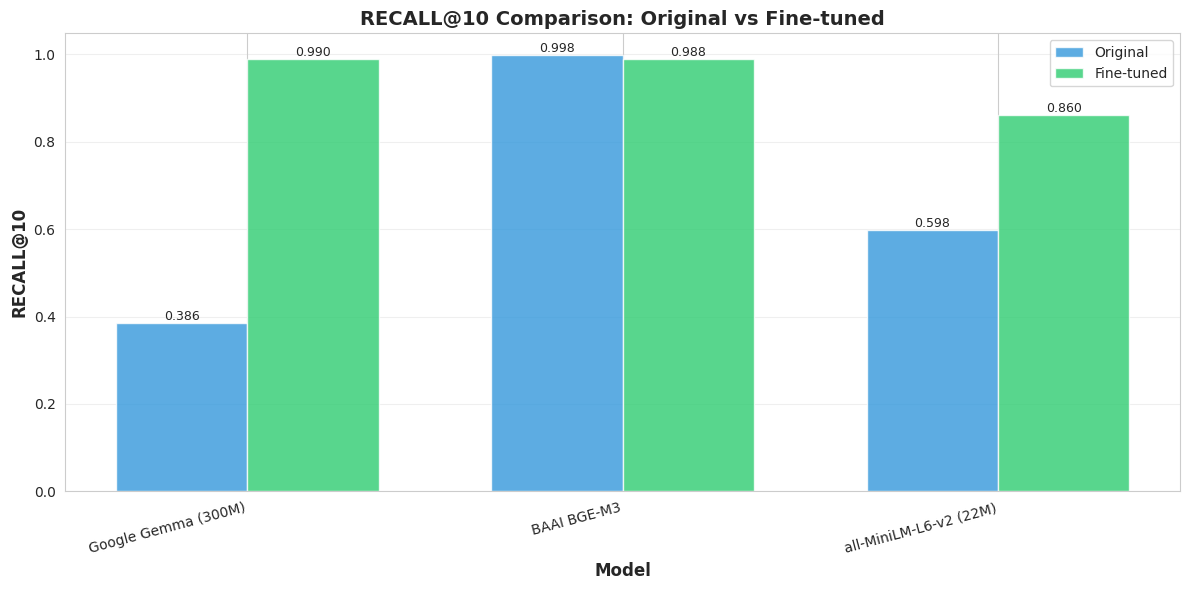

Created RECALL@10 comparison plot


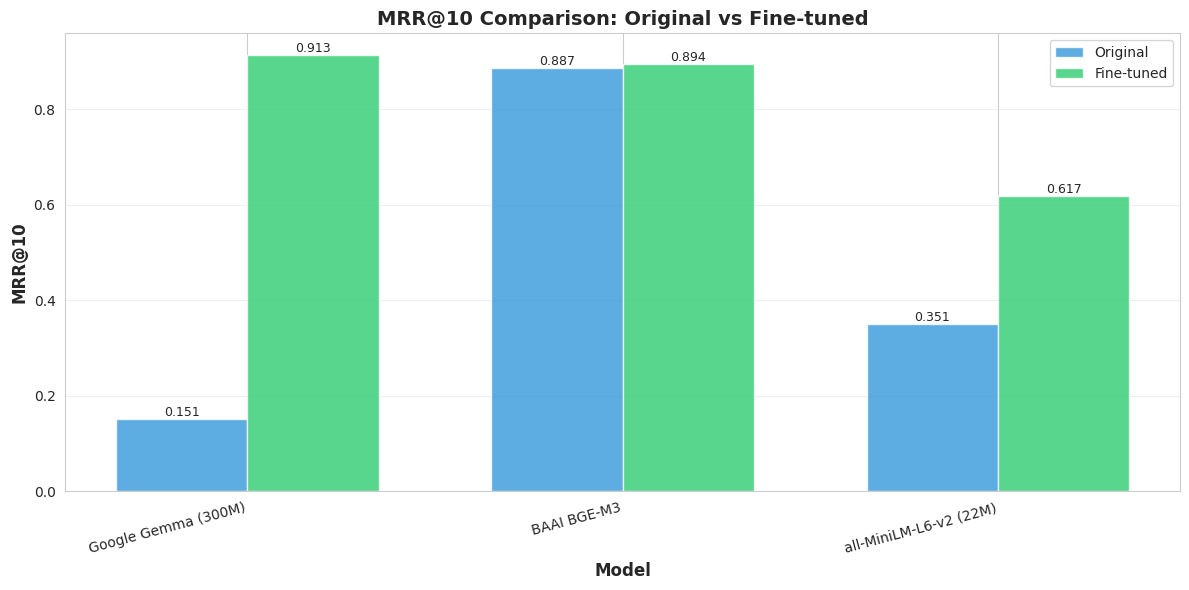

Created MRR@10 comparison plot


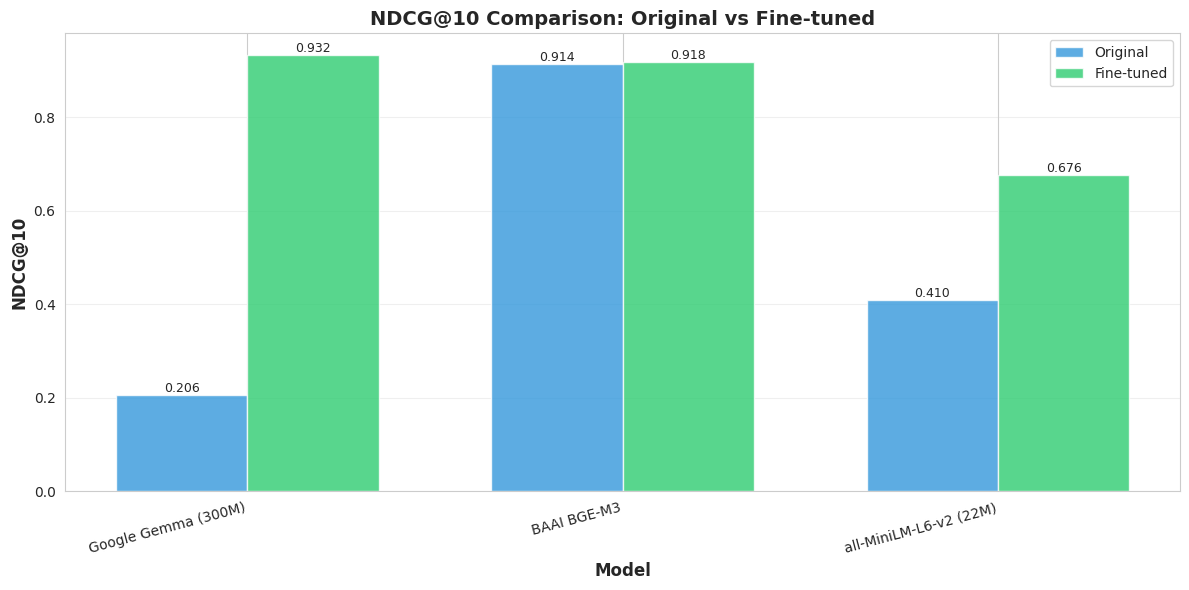

Created NDCG@10 comparison plot


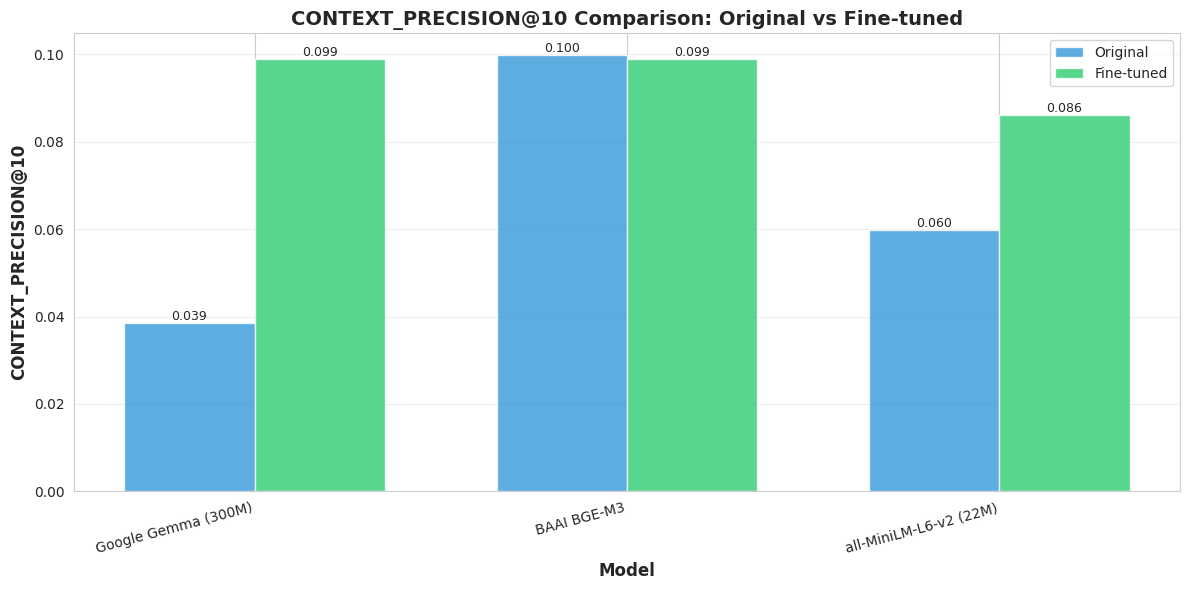

Created CONTEXT_PRECISION@10 comparison plot


In [33]:
# Visualization: Comparison plots
def plot_metric_comparison(metric_name: str, k_value: int = 10):
    """Plot comparison of a metric between original and fine-tuned models"""
    
    models_list = []
    original_values = []
    finetuned_values = []
    
    for base_model in ['gemma', 'bge_m3', 'minilm']:
        finetuned_key = f"{base_model}_finetuned"
        original_key = f"{base_model}_original"
        
        if finetuned_key in all_results and original_key in all_results:
            models_list.append(MODEL_DISPLAY_NAMES[base_model])
            original_values.append(all_results[original_key]['metrics'][metric_name][k_value])
            finetuned_values.append(all_results[finetuned_key]['metrics'][metric_name][k_value])
    
    x = np.arange(len(models_list))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width/2, original_values, width, label='Original', alpha=0.8, color='#3498db')
    bars2 = ax.bar(x + width/2, finetuned_values, width, label='Fine-tuned', alpha=0.8, color='#2ecc71')
    
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric_name.upper()}@{k_value}', fontsize=12, fontweight='bold')
    ax.set_title(f'{metric_name.upper()}@{k_value} Comparison: Original vs Fine-tuned', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=15, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    return fig

# Create comparison plots for all metrics at k=10
print("Creating comparison visualizations...")

for metric_name in ['recall', 'mrr', 'ndcg', 'context_precision']:
    fig = plot_metric_comparison(metric_name, k_value=10)
    plt.show()
    print(f"Created {metric_name.upper()}@10 comparison plot")

Creating metrics-by-K visualizations...


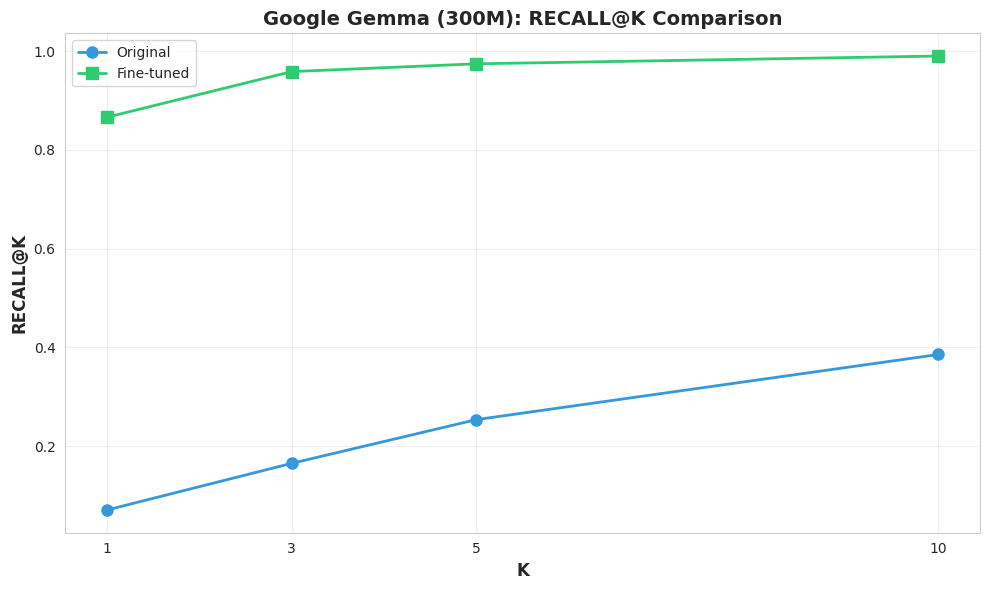

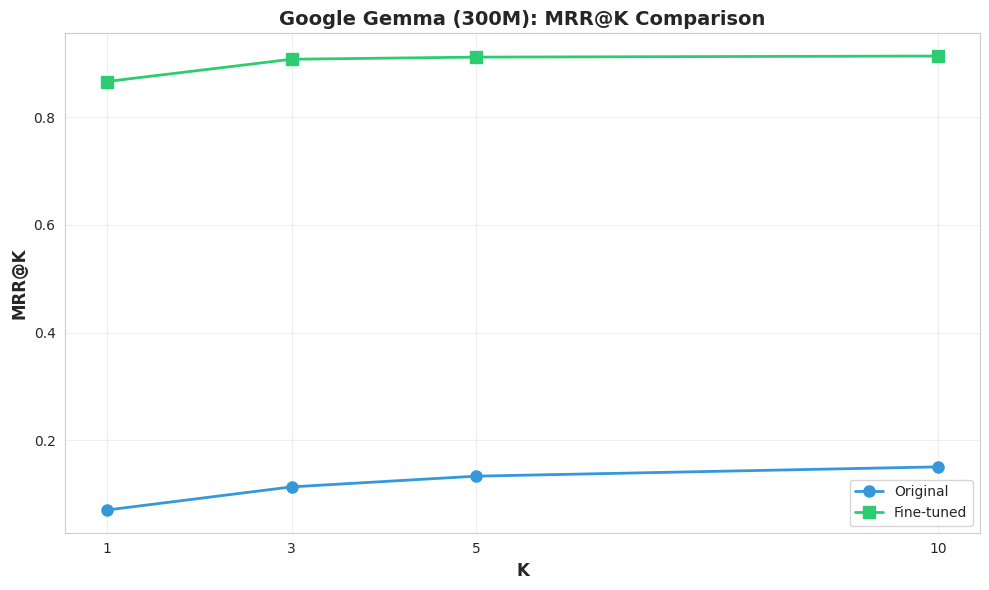

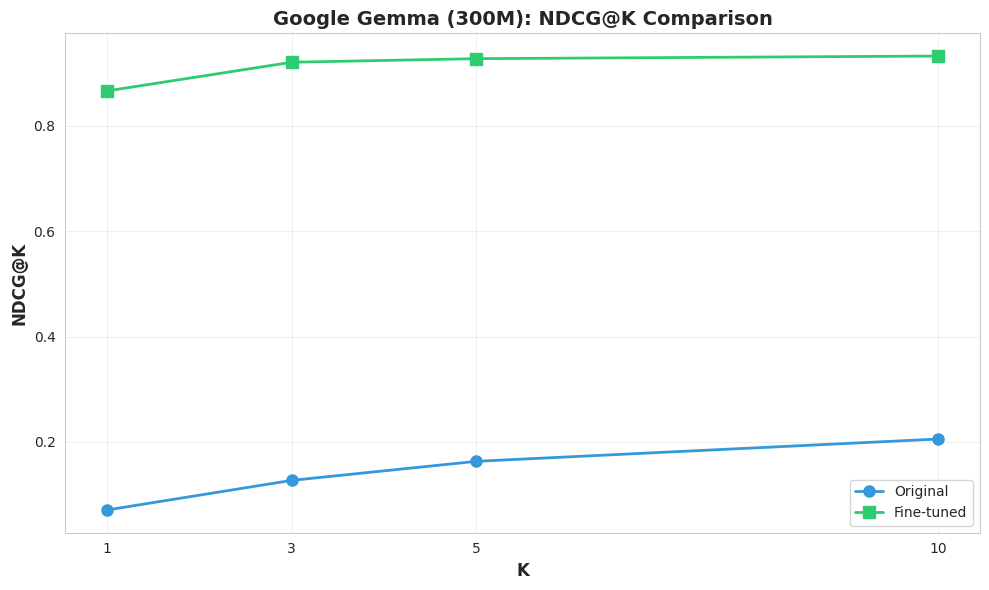

Created plots for Google Gemma (300M)


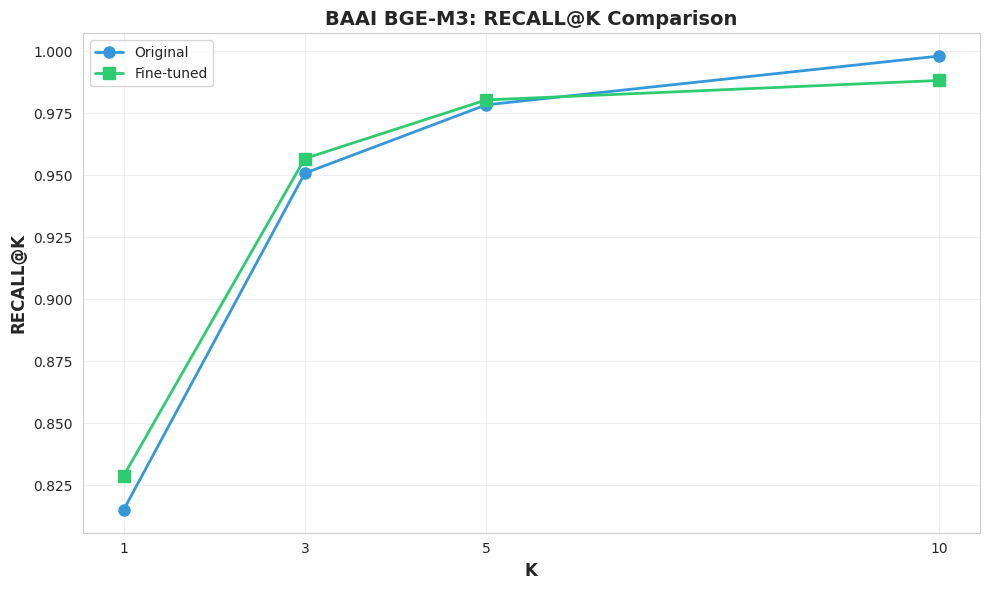

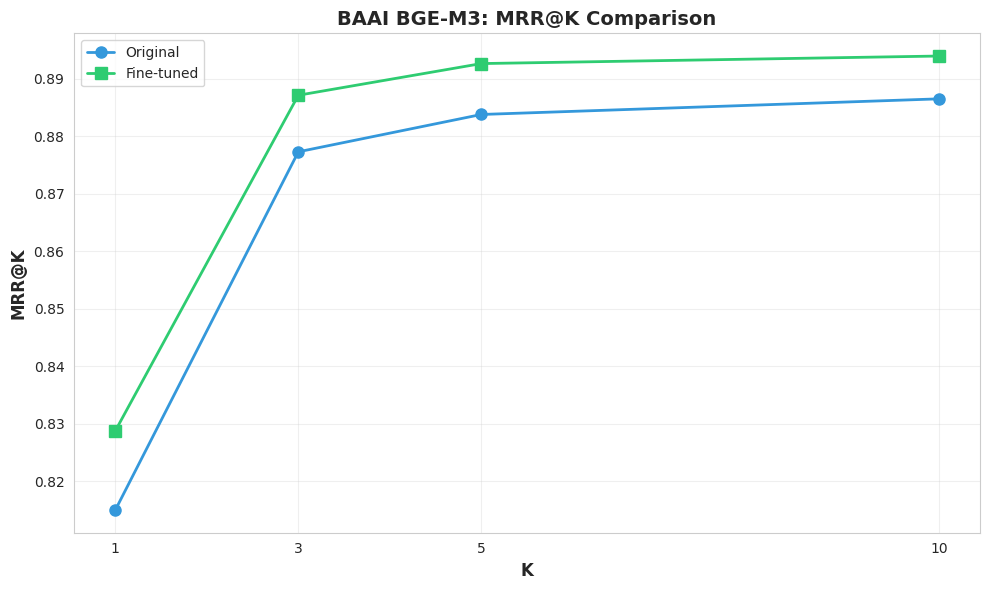

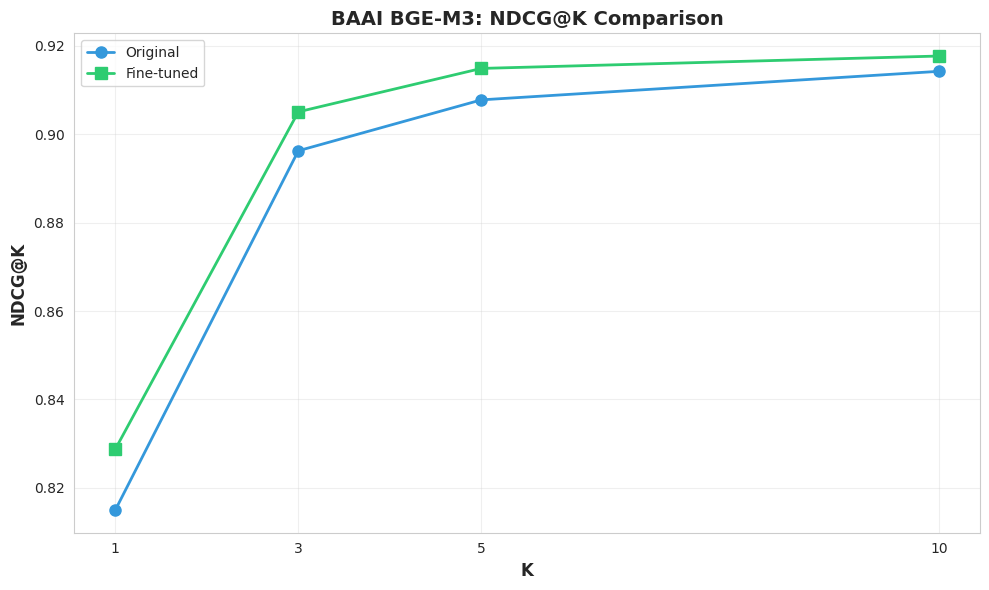

Created plots for BAAI BGE-M3


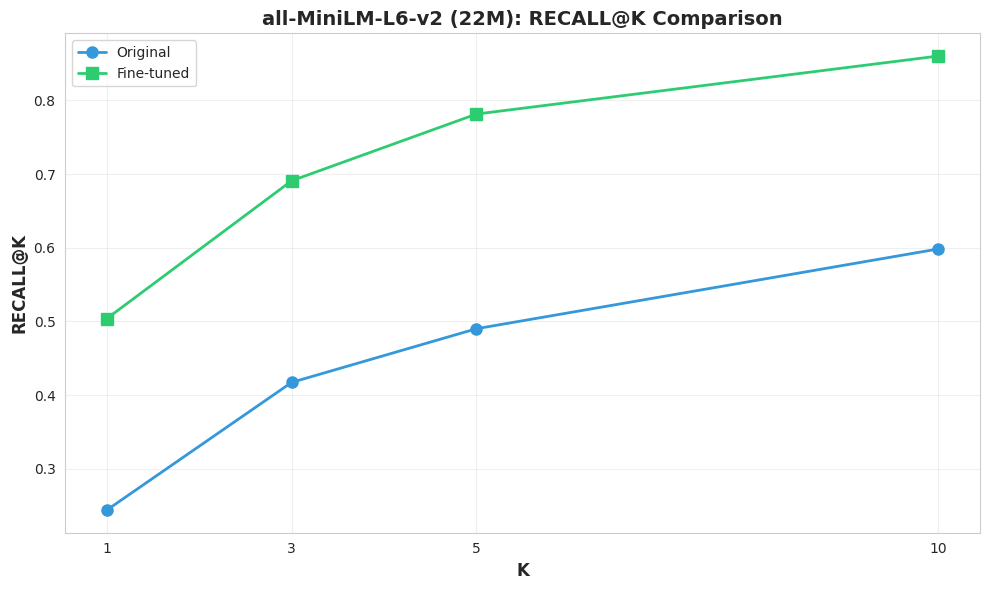

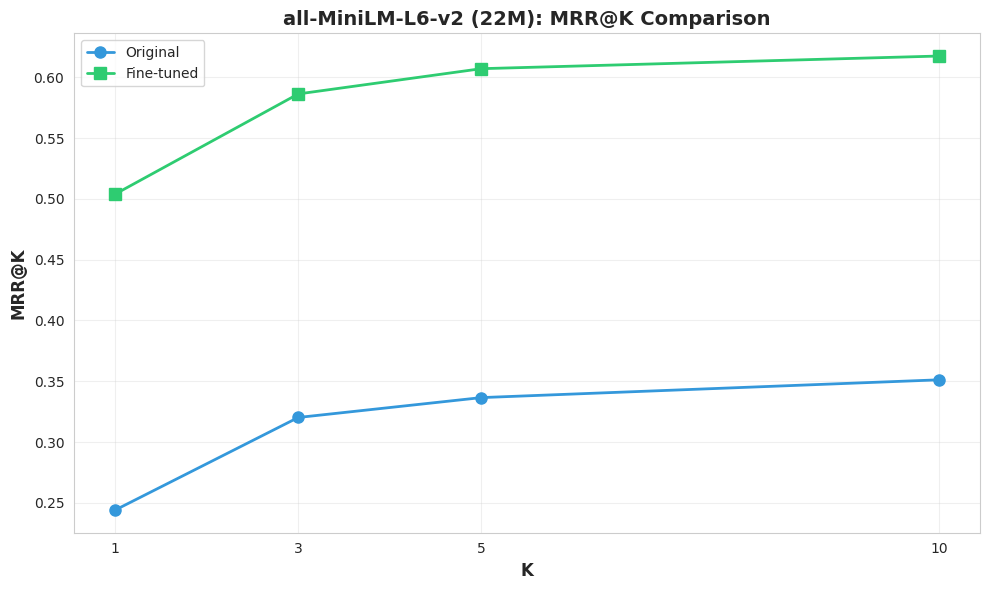

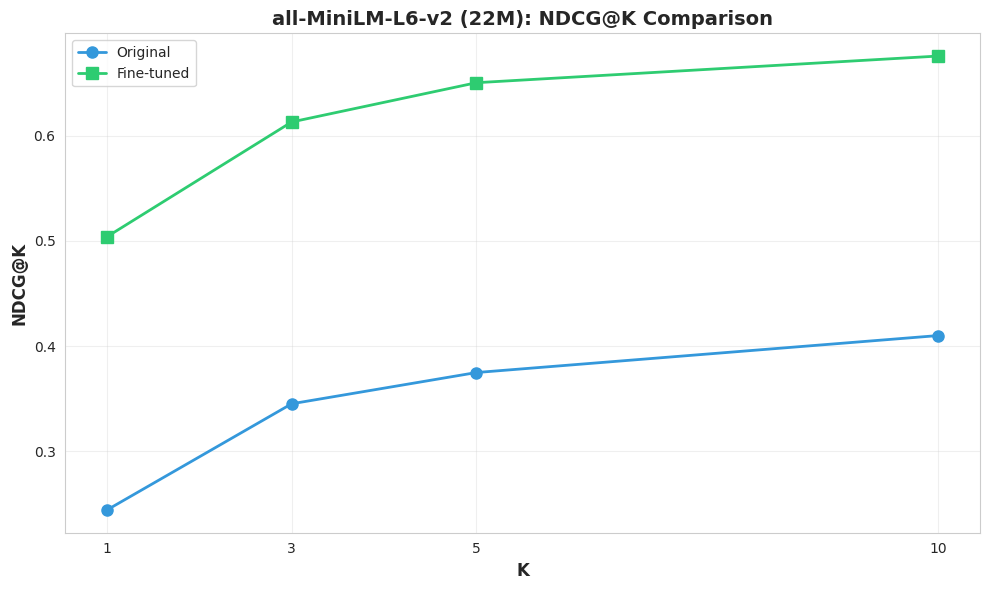

Created plots for all-MiniLM-L6-v2 (22M)


In [34]:
# Plot metrics across different K values
def plot_metrics_by_k(base_model: str, metric_name: str):
    """Plot a metric across different K values for both original and fine-tuned"""
    
    finetuned_key = f"{base_model}_finetuned"
    original_key = f"{base_model}_original"
    
    if finetuned_key not in all_results or original_key not in all_results:
        return None
    
    finetuned_values = [all_results[finetuned_key]['metrics'][metric_name][k] for k in K_VALUES]
    original_values = [all_results[original_key]['metrics'][metric_name][k] for k in K_VALUES]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(K_VALUES, original_values, marker='o', label='Original', linewidth=2, markersize=8, color='#3498db')
    ax.plot(K_VALUES, finetuned_values, marker='s', label='Fine-tuned', linewidth=2, markersize=8, color='#2ecc71')
    
    ax.set_xlabel('K', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric_name.upper()}@K', fontsize=12, fontweight='bold')
    ax.set_title(f'{MODEL_DISPLAY_NAMES[base_model]}: {metric_name.upper()}@K Comparison', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(K_VALUES)
    
    plt.tight_layout()
    return fig

# Create plots for each model and metric
print("Creating metrics-by-K visualizations...")

for base_model in ['gemma', 'bge_m3', 'minilm']:
    for metric_name in ['recall', 'mrr', 'ndcg']:
        fig = plot_metrics_by_k(base_model, metric_name)
        if fig is not None:
            plt.show()
    print(f"Created plots for {MODEL_DISPLAY_NAMES[base_model]}")

Creating similarity distribution plots...


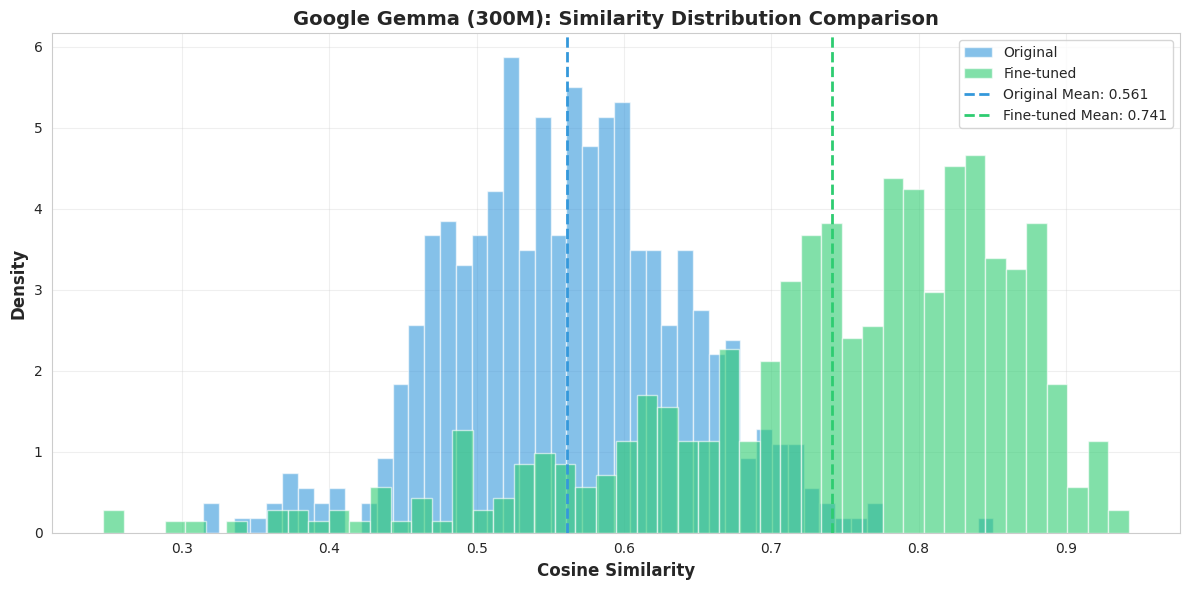

Created similarity distribution for Google Gemma (300M)


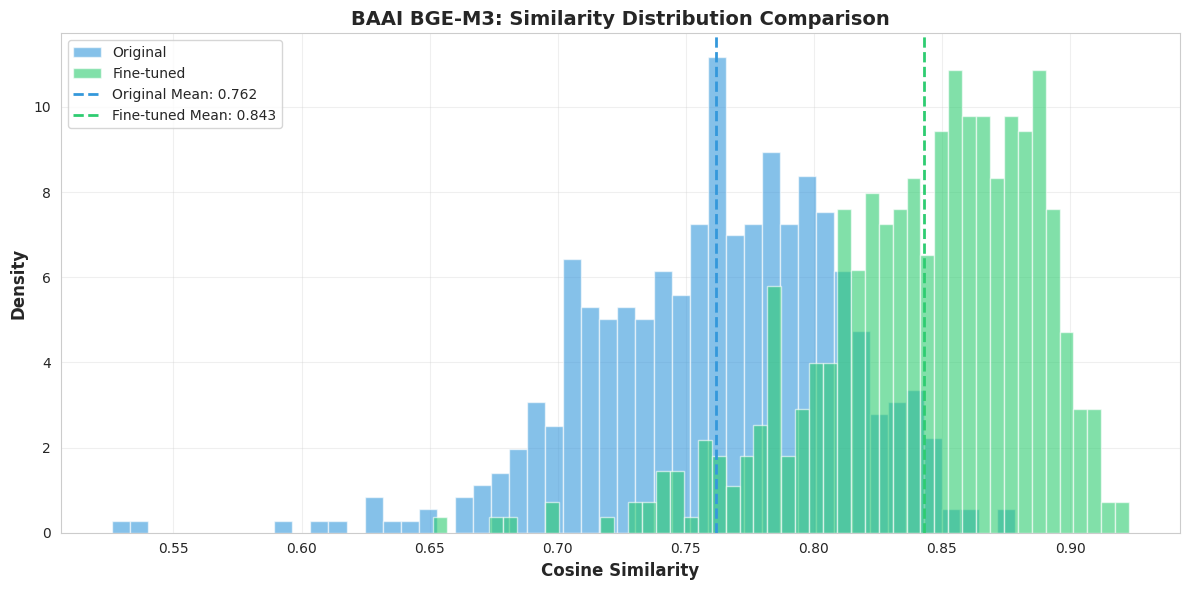

Created similarity distribution for BAAI BGE-M3


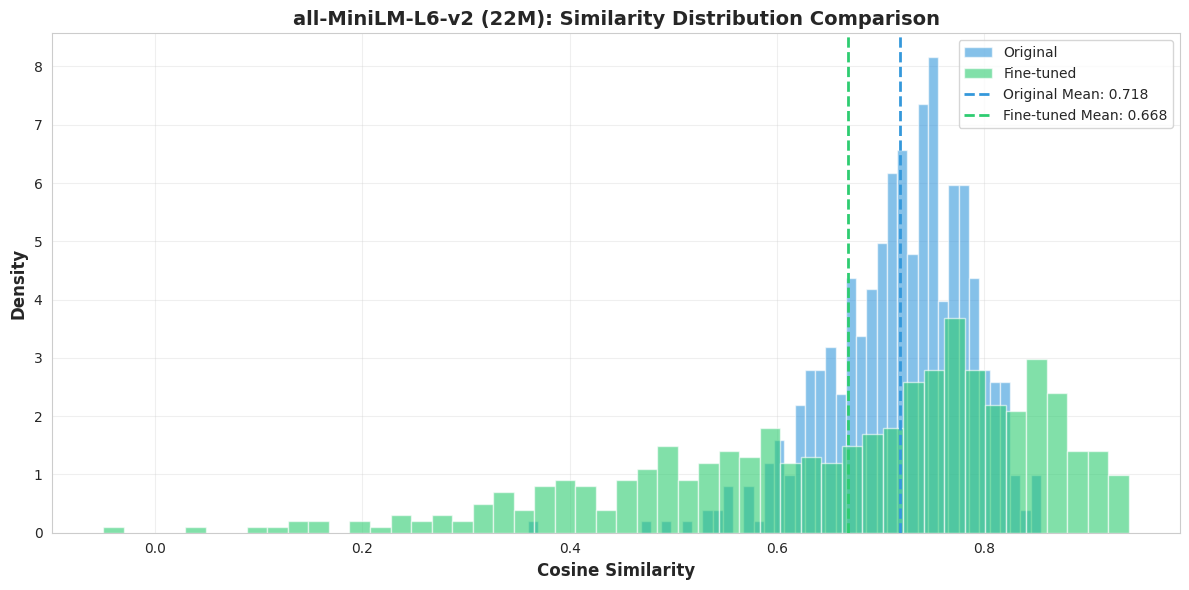

Created similarity distribution for all-MiniLM-L6-v2 (22M)


In [35]:
# Similarity distribution comparison
def plot_similarity_distribution(base_model: str):
    """Plot similarity distribution for original vs fine-tuned"""
    
    finetuned_key = f"{base_model}_finetuned"
    original_key = f"{base_model}_original"
    
    if finetuned_key not in all_results or original_key not in all_results:
        return None
    
    original_similarities = all_results[original_key]['similarity_stats']['values']
    finetuned_similarities = all_results[finetuned_key]['similarity_stats']['values']
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.hist(original_similarities, bins=50, alpha=0.6, label='Original', color='#3498db', density=True)
    ax.hist(finetuned_similarities, bins=50, alpha=0.6, label='Fine-tuned', color='#2ecc71', density=True)
    
    ax.axvline(np.mean(original_similarities), color='#3498db', linestyle='--', linewidth=2, label=f'Original Mean: {np.mean(original_similarities):.3f}')
    ax.axvline(np.mean(finetuned_similarities), color='#2ecc71', linestyle='--', linewidth=2, label=f'Fine-tuned Mean: {np.mean(finetuned_similarities):.3f}')
    
    ax.set_xlabel('Cosine Similarity', fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax.set_title(f'{MODEL_DISPLAY_NAMES[base_model]}: Similarity Distribution Comparison', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Create similarity distribution plots
print("Creating similarity distribution plots...")

for base_model in ['gemma', 'bge_m3', 'minilm']:
    fig = plot_similarity_distribution(base_model)
    if fig is not None:
        plt.show()
        print(f"Created similarity distribution for {MODEL_DISPLAY_NAMES[base_model]}")

In [36]:
# Save results to CSV
output_dir = BASE_DIR / "evaluation"
output_dir.mkdir(exist_ok=True)

from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save detailed results
results_csv_path = output_dir / f"benchmark_results_{timestamp}.csv"
results_df.to_csv(results_csv_path, index=False)
print(f"Saved detailed results to: {results_csv_path}")

# Save comparison results
comparison_csv_path = output_dir / f"comparison_finetuned_vs_original_{timestamp}.csv"
comparison_df.to_csv(comparison_csv_path, index=False)
print(f"Saved comparison results to: {comparison_csv_path}")

print(f"\nAll results saved to: {output_dir}")

Saved detailed results to: /home/nhotin/work/LegalBizAI_project/finetune/embedding_models/evaluation/benchmark_results_20251106_153655.csv
Saved comparison results to: /home/nhotin/work/LegalBizAI_project/finetune/embedding_models/evaluation/comparison_finetuned_vs_original_20251106_153655.csv

All results saved to: /home/nhotin/work/LegalBizAI_project/finetune/embedding_models/evaluation


In [37]:
# Final summary report
print("\n" + "=" * 100)
print("FINAL BENCHMARK SUMMARY")
print("=" * 100)

for base_model in ['gemma', 'bge_m3', 'minilm']:
    finetuned_key = f"{base_model}_finetuned"
    original_key = f"{base_model}_original"
    
    if finetuned_key in all_results and original_key in all_results:
        finetuned_results = all_results[finetuned_key]
        original_results = all_results[original_key]
        
        model_display_name = MODEL_DISPLAY_NAMES[base_model]
        
        print(f"\n{model_display_name}")
        print("-" * 100)
        
        # Key metrics at K=10
        recall_orig = original_results['metrics']['recall'][10]
        recall_ft = finetuned_results['metrics']['recall'][10]
        recall_improve = recall_ft - recall_orig
        recall_improve_pct = (recall_improve / recall_orig * 100) if recall_orig > 0 else 0
        
        mrr_orig = original_results['metrics']['mrr'][10]
        mrr_ft = finetuned_results['metrics']['mrr'][10]
        mrr_improve = mrr_ft - mrr_orig
        mrr_improve_pct = (mrr_improve / mrr_orig * 100) if mrr_orig > 0 else 0
        
        print(f"   Recall@10:    {recall_orig:.4f} → {recall_ft:.4f} ({recall_improve:+.4f}, {recall_improve_pct:+.2f}%)")
        print(f"   MRR@10:        {mrr_orig:.4f} → {mrr_ft:.4f} ({mrr_improve:+.4f}, {mrr_improve_pct:+.2f}%)")
        print(f"   Mean Similarity: {original_results['similarity_stats']['mean']:.4f} → {finetuned_results['similarity_stats']['mean']:.4f}")
        
        # Overall verdict
        total_improvement = recall_improve + mrr_improve
        if total_improvement > 0.05:
            verdict = "SIGNIFICANT IMPROVEMENT"
        elif total_improvement > 0:
            verdict = "MODERATE IMPROVEMENT"
        elif total_improvement > -0.05:
            verdict = "MINIMAL CHANGE"
        else:
            verdict = "REGRESSION"
        
        print(f"   Verdict: {verdict}")

print("\n" + "=" * 100)
print("Benchmark completed successfully!")
print("=" * 100)


FINAL BENCHMARK SUMMARY

Google Gemma (300M)
----------------------------------------------------------------------------------------------------
   Recall@10:    0.3858 → 0.9902 (+0.6043, +156.63%)
   MRR@10:        0.1510 → 0.9134 (+0.7624, +504.97%)
   Mean Similarity: 0.5614 → 0.7412
   Verdict: SIGNIFICANT IMPROVEMENT

BAAI BGE-M3
----------------------------------------------------------------------------------------------------
   Recall@10:    0.9980 → 0.9882 (-0.0098, -0.99%)
   MRR@10:        0.8865 → 0.8940 (+0.0075, +0.84%)
   Mean Similarity: 0.7619 → 0.8428
   Verdict: MINIMAL CHANGE

all-MiniLM-L6-v2 (22M)
----------------------------------------------------------------------------------------------------
   Recall@10:    0.5984 → 0.8602 (+0.2618, +43.75%)
   MRR@10:        0.3512 → 0.6175 (+0.2663, +75.83%)
   Mean Similarity: 0.7183 → 0.6685
   Verdict: SIGNIFICANT IMPROVEMENT

Benchmark completed successfully!
